# README Figure Generator

This notebook produces all figures used in the ANDES README and contains the
full README draft as the final cell. Run all cells to regenerate figures into
`images/readme/`, then copy the last markdown cell to `README.md`.

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import andes

andes.config_logger(stream_level=30)

OUTDIR = Path("images/readme")
OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

## Figure 1: Quick Start (PSS/E RAW + DYR)

Load a PSS/E case, add a bus fault programmatically, simulate, and plot.
This is the main figure shown near the top of the README.

In [2]:
# This mirrors the quick-start snippet shown in the README
ss = andes.load(
    andes.get_case("ieee14/ieee14.raw"),
    addfile=andes.get_case("ieee14/ieee14.dyr"),
    setup=False,
)
ss.add("Fault", bus=2, tf=1.0, tc=1.1)
ss.setup()

ss.PFlow.run()
ss.TDS.config.tf = 10
ss.TDS.run()

  0%|          | 0/100 [00:00<?, ?%/s]

True

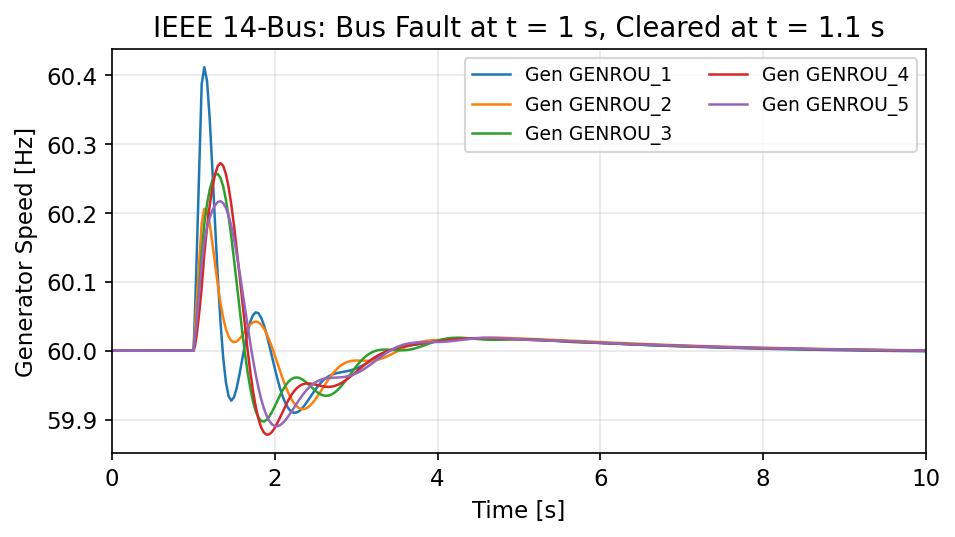

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))

ts = ss.TDS.get_timeseries(ss.GENROU.omega)
for col in ts.columns:
    ax.plot(ts.index, ts[col] * 60, linewidth=1.2)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Generator Speed [Hz]")
ax.set_title("IEEE 14-Bus: Bus Fault at t = 1 s, Cleared at t = 1.1 s")
ax.legend([f"Gen {i}" for i in ss.GENROU.idx.v],
          loc="upper right", fontsize=9, ncol=2)
ax.set_xlim(0, 10)

fig.savefig(OUTDIR / "demo_tds.png")
plt.show()

## Figure 2: Eigenvalue Analysis

Run small-signal stability analysis on the Kundur two-area system.

In [4]:
ss_eig = andes.load(andes.get_case("kundur/kundur_full.xlsx"))
ss_eig.PFlow.run()
ss_eig.EIG.run()

True

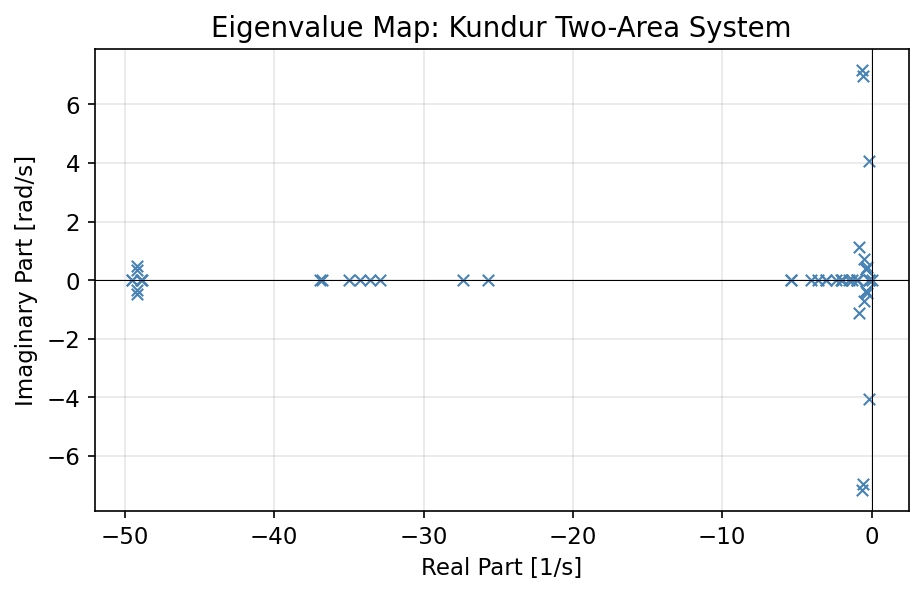

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

eigs = ss_eig.EIG.mu
ax.scatter(eigs.real, eigs.imag, marker="x", s=30, c="steelblue", linewidths=1.0)
ax.axvline(0, color="k", linewidth=0.5)
ax.axhline(0, color="k", linewidth=0.5)
ax.set_xlabel("Real Part [1/s]")
ax.set_ylabel("Imaginary Part [rad/s]")
ax.set_title("Eigenvalue Map: Kundur Two-Area System")

fig.savefig(OUTDIR / "eigenvalue_map.png")
plt.show()

## Figure 3: TGOV1 Symbolic Equations

Display auto-generated documentation and symbolic equations for the
descriptive modeling section.

In [6]:
ss_sym = andes.System()
ss_sym.TGOV1.prepare()

# Auto-generated documentation
print(ss_sym.TGOV1.doc())

Model <TGOV1> in Group <TurbineGov>
TGOV1 turbine governor model.

Implements the PSS/E TGOV1 model without deadband.

Parameters

 Name  |            Description            | Default | Unit |    Properties   
-------+-----------------------------------+---------+------+-----------------
 idx   | unique device idx                 |         |      |                 
 u     | connection status                 | 1       | bool |                 
 name  | device name                       |         |      |                 
 syn   | Synchronous generator idx         |         |      | mandatory,unique
 Tn    | Turbine power rating. Equal to    | 0       | MVA  |                 
       | `Sn` if not provided.             |         |      |                 
 wref0 | Base speed reference              | 1       | p.u. |                 
 R     | Speed regulation gain (mach. base | 0.050   | p.u. | ipower          
       | default)                          |         |      |                 


In [7]:
# Symbolic differential and algebraic equations
print("Differential equations (T x' = f):")
display(ss_sym.TGOV1.syms.f)

print("\nAlgebraic equations (0 = g):")
display(ss_sym.TGOV1.syms.g)

Differential equations (T x' = f):


Matrix([
[ -LAG_y + pd],
[LAG_y - LL_x],
[           0]])


Algebraic equations (0 = g):


Matrix([
[                                                   -paux + paux0],
[                                      -pout + ue*(-Dt*wd + LL_y)],
[                                                   -wref + wref0],
[                                                  R*pref0 - pref],
[                                          ue*(omega - wref) - wd],
[                                 gain*ue*(paux + pref - wd) - pd],
[LL_LT_z1*(-LAG_y + LL_y) + LL_x*T3 - LL_y*T3 + T2*(LAG_y - LL_x)],
[                                                 ue*(pout - tm0)]])

## Model Library Summary

Count all groups and models for the capabilities section.

In [8]:
ss_doc = andes.System()
groups = {g: list(grp.models.keys()) for g, grp in ss_doc.groups.items() if grp.models}
total = sum(len(v) for v in groups.values())
print(f"{len(groups)} groups, {total} models\n")

for g in ["SynGen", "TurbineGov", "Exciter", "PSS",
          "RenGen", "RenExciter", "RenGovernor", "DG", "DynLoad"]:
    if g in groups:
        print(f"  {g}: {', '.join(groups[g])}")

37 groups, 101 models

  SynGen: GENCLS, GENROU, PLBVFU1
  TurbineGov: TG2, TGOV1, TGOV1DB, TGOV1N, TGOV1NDB, IEEEG1, IEESGO, GAST, HYGOV, HYGOVDB, HYGOV4
  Exciter: EXDC2, IEEEX1, ESDC1A, ESDC2A, EXST1, ESST3A, SEXS, IEEET1, EXAC1, EXAC2, EXAC4, ESST4B, AC8B, IEEET3, ESAC1A, ESST1A, ESAC5A
  PSS: IEEEST, ST2CUT
  RenGen: REGCA1, REGCP1, REGCV1, REGCV2, REGF1, REGF2, REGF3
  RenExciter: REECA1, REECA1E, REECA1G, REECB1
  RenGovernor: WTDTA1, WTDS
  DG: PVD1, ESD1, EV1, EV2
  DynLoad: ZIP, FLoad
